<H1>ЗАДАНИЕ РАСЧЕТНО-ГРАФИЧЕСКОЙ РАБОТЫ ПО
«МАТЕМАТИЧЕСКОЙ СТАТИСТИКЕ»</H1>


<H3>Выполнил: Каштанкин Т.И. МОАИСбд-21</H3>

Импортируем необходимые библиотеки:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import kagglehub
from kagglehub import KaggleDatasetAdapter

1 . В качестве источника данных я использовал датасет "Screen Time, Sleep & Stress Analysis Dataset" (Анализ экранного времени, сна, уровня стресса) от автора Amar Tiwari с сайта Kaggle. Для расчетной работы я выбрал следующие измерения:

Случайная величина X - экранное время (сколько часов в день человек использует телефон);

Случайная величина Y - уровень стресса (самооценка уровня стресса по шкале от 1 до 10).


In [2]:
orig_df = pd.read_csv("C:/Users/0_j/Documents/Smartphone_Usage_Productivity_Dataset_50000.csv")
display(orig_df.info())
display(orig_df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usag

None

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


В оригинальном датасете 50 000 строк и 13 столбцов. Поскольку для работы нам понадобится 2 величины и 100 измерений, будем использовать только первые 100 строк столбцов Daily_Phone_Hours и Stress_Level.

In [3]:
X_label = 'Daily_Phone_Hours' 
Y_label = 'Stress_Level'
df = orig_df[[X_label, Y_label]].head(100).copy()
df.columns = ['X', 'Y']
display(df)

,X,Y
0,1.3,4
1,1.2,1
2,5.3,4
3,5.8,3
4,7.9,3
...,...,...
95,3.0,6
96,8.7,1
97,5.5,6
98,10.7,1


2 . Составляем отдельные выборки для X и для Y

In [4]:
sample_x = df['X'].values
sample_y = df['Y'].values
print(f"Выборка X (n={len(sample_x)}):")
display(sample_x) 

print(f"\nВыборка Y (n={len(sample_y)}):")
display(sample_y)

Выборка X (n=100):


array([ 1.3,  1.2,  5.3,  5.8,  7.9, 10.9,  5.6,  8.5,  9.4,  2.8,  8.3,
       12. , 11.1,  9.7,  1.1, 11.6,  2.3, 10.8,  3.3,  3.9,  3.3,  9.5,
       10.9,  5.5,  3.7, 10.1,  1.2,  9.7, 11.7, 11.4,  2.1,  5.8,  8.2,
        3.4, 11.8,  7.1,  3.8,  3.9,  8.3,  1.8,  3.4,  9.6,  1.2,  1. ,
        1.5,  9. ,  5.5,  5.2, 10.4,  8.1,  9.7,  6.8,  4. ,  6. , 11.7,
        6.3,  3.8,  3.5,  2. ,  9.8,  1.4,  9.7,  5. ,  3.9,  5.7,  5.7,
        8.1,  3.7, 10.2,  7.4,  3.7,  4.3, 11.5,  9.1,  4.5, 10.1,  6.7,
       10.2,  6.6,  1.6,  4.7, 11.7, 11.3,  8.6, 10.8,  2.9,  9.3,  9.4,
       11.4, 10.3,  6.4, 10.3,  1.5,  1.4,  3.7,  3. ,  8.7,  5.5, 10.7,
        9.4])


Выборка Y (n=100):


array([ 4,  1,  4,  3,  3,  7,  3,  3,  4,  2,  9, 10,  4,  1,  8,  5,  1,
        5,  1,  5,  1,  6,  8,  8,  6, 10, 10, 10, 10,  7,  9, 10,  6,  6,
        1,  5,  2,  5,  5, 10,  2,  7,  8, 10,  9,  4,  9,  1,  8,  2,  4,
       10,  9,  1,  3,  4,  9,  1,  6,  8,  8,  5,  3,  6,  2,  1,  5,  4,
       10,  9,  6,  4,  7, 10,  7,  2,  8,  8,  9,  6,  5,  4,  1,  3,  4,
        8,  5,  4,  9, 10,  6, 10,  4,  1,  8,  6,  1,  6,  1,  9])

3 . Составляем вариационные ряды (сортируем массивы по возрастанию)

In [5]:
variational_x = np.sort(sample_x)
variational_y = np.sort(sample_y)

print("Вариационный ряд X:", variational_x)
print("Вариационный ряд Y:", variational_y)

Вариационный ряд X: [ 1.   1.1  1.2  1.2  1.2  1.3  1.4  1.4  1.5  1.5  1.6  1.8  2.   2.1
  2.3  2.8  2.9  3.   3.3  3.3  3.4  3.4  3.5  3.7  3.7  3.7  3.7  3.8
  3.8  3.9  3.9  3.9  4.   4.3  4.5  4.7  5.   5.2  5.3  5.5  5.5  5.5
  5.6  5.7  5.7  5.8  5.8  6.   6.3  6.4  6.6  6.7  6.8  7.1  7.4  7.9
  8.1  8.1  8.2  8.3  8.3  8.5  8.6  8.7  9.   9.1  9.3  9.4  9.4  9.4
  9.5  9.6  9.7  9.7  9.7  9.7  9.8 10.1 10.1 10.2 10.2 10.3 10.3 10.4
 10.7 10.8 10.8 10.9 10.9 11.1 11.3 11.4 11.4 11.5 11.6 11.7 11.7 11.7
 11.8 12. ]
Вариационный ряд Y: [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  2  2  2  2  2  2  3  3  3  3
  3  3  3  4  4  4  4  4  4  4  4  4  4  4  4  4  5  5  5  5  5  5  5  5
  5  5  6  6  6  6  6  6  6  6  6  6  6  7  7  7  7  7  8  8  8  8  8  8
  8  8  8  8  8  9  9  9  9  9  9  9  9  9  9 10 10 10 10 10 10 10 10 10
 10 10 10 10]


4 . Составляем группированные выборки для X и Y с числом интервалов k=10

In [6]:
#Группированные выборки для X:
k=10
x_min=sample_x.min()
x_max=sample_x.max()
R_x = x_max - x_min
w_x = R_x / k

print(f"Размах выборки СВ X: {R_x}, ширина интервала: {w_x}")
bins_x = [x_min + i * w_x for i in range(k + 1)] #создаем границы интервалов
df_x = pd.DataFrame({
    'Границы интервалов X': [f"[{bins_x[i]:.1f}; {bins_x[i+1]:.1f}]" for i in range(len(bins_x)-1)],
})
display(df_x)

#Группированные выборки для Y:
k=10
y_min=sample_y.min()
y_max=sample_y.max()
R_y = y_max - y_min
w_y = R_y / k

print(f"Размах выборки СВ Y: {R_y}, ширина интервала: {w_y}")
bins_y = [y_min + i * w_y for i in range(k + 1)] #создаем границы интервалов
df_y = pd.DataFrame({
    'Границы интервалов Y': [f"[{bins_y[i]:.1f}; {bins_y[i+1]:.1f}]" for i in range(len(bins_y)-1)]
})
display(df_y)

Размах выборки СВ X: 11.0, ширина интервала: 1.1


,Границы интервалов X
0,[1.0; 2.1]
1,[2.1; 3.2]
2,[3.2; 4.3]
3,[4.3; 5.4]
4,[5.4; 6.5]
5,[6.5; 7.6]
6,[7.6; 8.7]
7,[8.7; 9.8]
8,[9.8; 10.9]
9,[10.9; 12.0]


Размах выборки СВ Y: 9, ширина интервала: 0.9


,Границы интервалов Y
0,[1.0; 1.9]
1,[1.9; 2.8]
2,[2.8; 3.7]
3,[3.7; 4.6]
4,[4.6; 5.5]
5,[5.5; 6.4]
6,[6.4; 7.3]
7,[7.3; 8.2]
8,[8.2; 9.1]
9,[9.1; 10.0]


Теперь ищем середины интервалов (Z<sub>i</sub>), частоты (n<sub>i</sub>), относительные частоты (n<sub>i</sub>/n), накопленные частоты (Σn<sub>i</sub>), накопленные относительные частоты (Σn<sub>i</sub>/n) и плотность относительной частоты (n<sub>i</sub>/wn)

In [7]:
#Для СВ X:
z_i_x = [(bins_x[i] + bins_x[i+1]) / 2 for i in range(k)]
intervals_x = pd.cut(sample_x, bins=bins_x, include_lowest=True)
n_i_x = intervals_x.value_counts().sort_index()
df_x['z_i']=z_i_x
df_x['n_i']=n_i_x.values
df_x['n_i/n'] = df_x['n_i'] / 100 #т.к. n=100
df_x['sum_n_i'] = df_x['n_i'].cumsum()
df_x['sum_n_i/n'] = df_x['n_i/n'].cumsum()
df_x['n_i/(n*w)'] = df_x['n_i'] / (w_x*100)
display(df_x)
#Для СВ Y:
z_i_y = [(bins_y[i] + bins_y[i+1]) / 2 for i in range(k)]
intervals_y = pd.cut(sample_y, bins=bins_y, include_lowest=True)
n_i_y = intervals_y.value_counts().sort_index()
df_y['z_i']=z_i_y
df_y['n_i']=n_i_y.values
df_y['n_i/n'] = df_y['n_i'] / 100 #т.к. n=100
df_y['sum_n_i'] = df_y['n_i'].cumsum()
df_y['sum_n_i/n'] = df_y['n_i/n'].cumsum()
df_y['n_i/(n*w)'] = df_y['n_i'] / (w_x*100)
display(df_y)

,Границы интервалов X,z_i,n_i,n_i/n,sum_n_i,sum_n_i/n,n_i/(n*w)
0,[1.0; 2.1],1.55,14,0.14,14,0.14,0.127273
1,[2.1; 3.2],2.65,4,0.04,18,0.18,0.036364
2,[3.2; 4.3],3.75,16,0.16,34,0.34,0.145455
3,[4.3; 5.4],4.85,5,0.05,39,0.39,0.045455
4,[5.4; 6.5],5.95,11,0.11,50,0.50,0.100000
5,[6.5; 7.6],7.05,5,0.05,55,0.55,0.045455
6,[7.6; 8.7],8.15,9,0.09,64,0.64,0.081818
7,[8.7; 9.8],9.25,13,0.13,77,0.77,0.118182
8,[9.8; 10.9],10.35,12,0.12,89,0.89,0.109091
9,[10.9; 12.0],11.45,11,0.11,100,1.00,0.100000


,Границы интервалов Y,z_i,n_i,n_i/n,sum_n_i,sum_n_i/n,n_i/(n*w)
0,[1.0; 1.9],1.45,14,0.14,14,0.14,0.127273
1,[1.9; 2.8],2.35,6,0.06,20,0.20,0.054545
2,[2.8; 3.7],3.25,7,0.07,27,0.27,0.063636
3,[3.7; 4.6],4.15,13,0.13,40,0.40,0.118182
4,[4.6; 5.5],5.05,10,0.10,50,0.50,0.090909
5,[5.5; 6.4],5.95,11,0.11,61,0.61,0.100000
6,[6.4; 7.3],6.85,5,0.05,66,0.66,0.045455
7,[7.3; 8.2],7.75,11,0.11,77,0.77,0.100000
8,[8.2; 9.1],8.65,10,0.10,87,0.87,0.090909
9,[9.1; 10.0],9.55,13,0.13,100,1.00,0.118182


5 . Теперь строим гистограмму частот, полигон частот и выборочную функцию распределения для X и Y

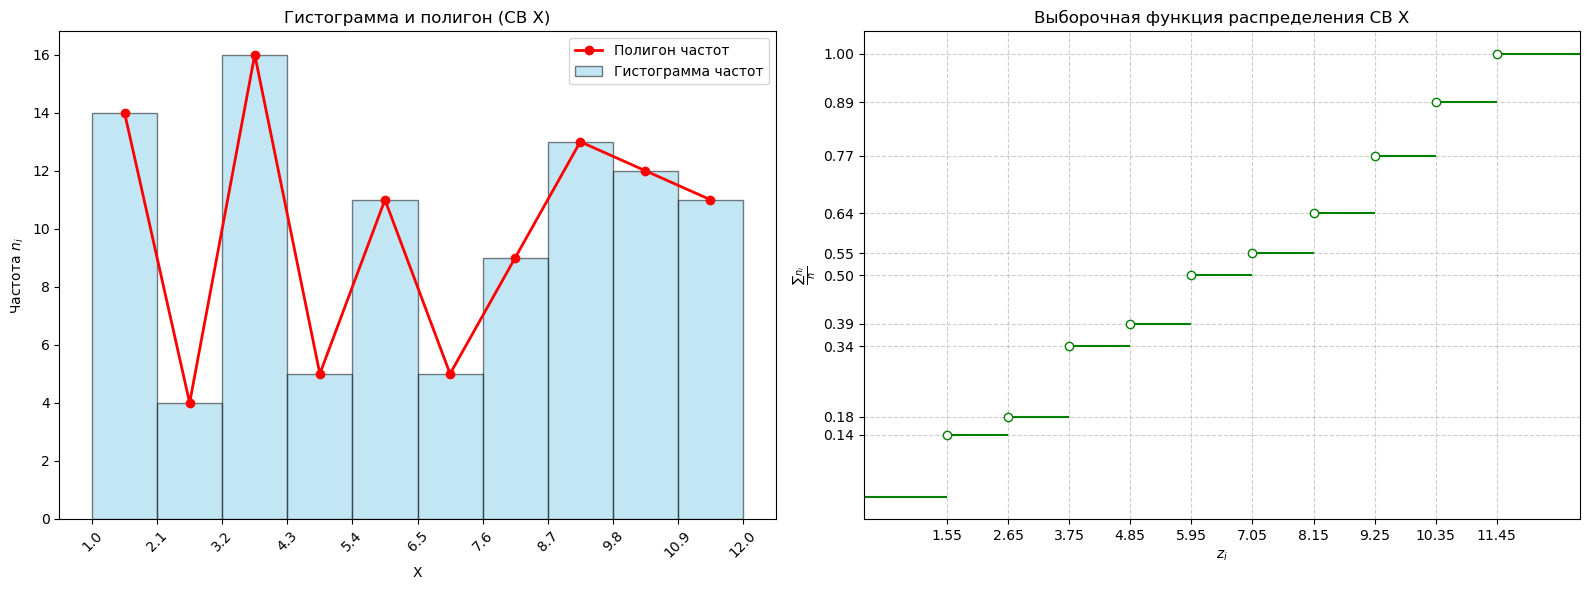

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(bins_x[:-1], df_x['n_i'], width=w_x, color='skyblue', 
        edgecolor='black', alpha=0.5, align='edge', label='Гистограмма частот')
ax1.plot(df_x['z_i'], df_x['n_i'], marker='o', color='red', 
         linewidth=2, label='Полигон частот')
ax1.set_title('Гистограмма и полигон (СВ X)')
ax1.set_xlabel('X')
ax1.set_ylabel('Частота $n_i$')
ax1.set_xticks(bins_x)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()

z_i = df_x['z_i'].values
y_val = df_x['sum_n_i/n'].values
margin = 1.5
x_min, x_max = z_i[0] - margin, z_i[-1] + margin

ax2.hlines(y=0, xmin=x_min, xmax=z_i[0], color='green')
for i in range(len(z_i) - 1):
    ax2.hlines(y=y_val[i], xmin=z_i[i], xmax=z_i[i+1], color='green')
ax2.hlines(y=1, xmin=z_i[-1], xmax=x_max, color='green')

ax2.scatter(z_i, y_val, edgecolors='green', facecolors='white', zorder=3)
ax2.set_xticks(z_i)
ax2.set_yticks(y_val)
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_title('Выборочная функция распределения СВ X')
ax2.set_xlabel('$z_i$')
ax2.set_ylabel(r'$\frac{\sum n_i}{n}$')

plt.tight_layout()
plt.show()

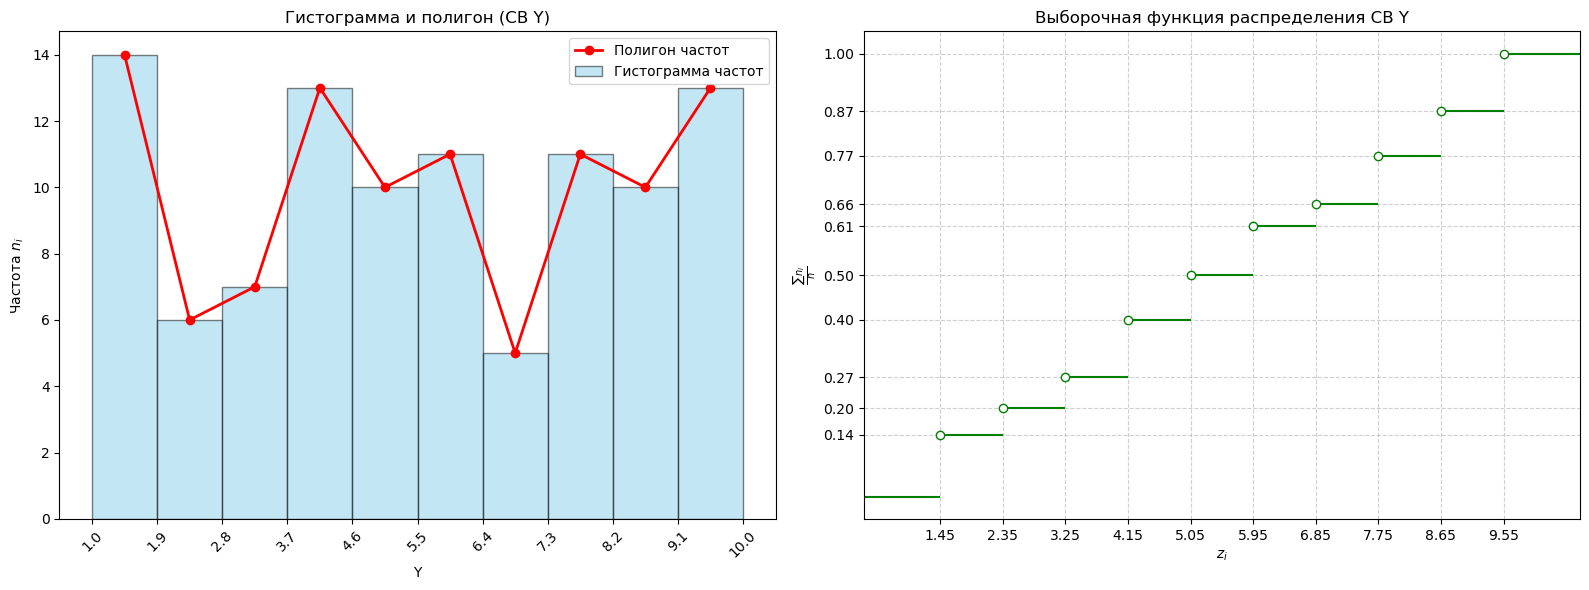

In [9]:
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

ax3.bar(bins_y[:-1], df_y['n_i'], width=w_y, color='skyblue', 
        edgecolor='black', alpha=0.5, align='edge', label='Гистограмма частот')
ax3.plot(df_y['z_i'], df_y['n_i'], marker='o', color='red', 
         linewidth=2, label='Полигон частот')
ax3.set_title('Гистограмма и полигон (СВ Y)')
ax3.set_xlabel('Y')
ax3.set_ylabel('Частота $n_i$')
ax3.set_xticks(bins_y)
ax3.tick_params(axis='x', rotation=45)
ax3.legend()

z_i_y = df_y['z_i'].values
y_val_y = df_y['sum_n_i/n'].values
margin_y = 1.1
x_min_y, x_max_y = z_i_y[0] - margin_y, z_i_y[-1] + margin_y

ax4.hlines(y=0, xmin=x_min_y, xmax=z_i_y[0], color='green')
for i in range(len(z_i_y) - 1):
    ax4.hlines(y=y_val_y[i], xmin=z_i_y[i], xmax=z_i_y[i+1], color='green')
ax4.hlines(y=1, xmin=z_i_y[-1], xmax=x_max_y, color='green')

ax4.scatter(z_i_y, y_val_y, edgecolors='green', facecolors='white', zorder=3)
ax4.set_xticks(z_i_y)
ax4.set_yticks(y_val_y)
ax4.set_xlim(x_min_y, x_max_y)
ax4.set_ylim(-0.05, 1.05)
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.set_title('Выборочная функция распределения СВ Y')
ax4.set_xlabel('$z_i$')
ax4.set_ylabel(r'$\frac{\sum n_i}{n}$')

plt.tight_layout()
plt.show()

6 . По построеным графикам можно сделать вывод о том, что величины X и Y имеют <b>равномерное</b> распределение.

7 . Составляем точечные оценки математического ожидания и дисперсии для исходных и группированных выборок Х и Y.

Точечной оценкой мат. ожидания является среднее арифметическое. Оценка дисперсии определяется формулами.

In [10]:
n=100 #размер выборки. Можно было посчитать как len(sample_x)

mean_sample_x = sum(sample_x)/n #благодаря numpy можно было посчитать легче: sample_x.mean()
mean_variational_x = 1/n * (df_x['z_i'] * df_x['n_i']).sum()

var_est_sample_x = n/(n-1) * (1/n * sum(sample_x**2) - (mean_sample_x)**2)
std_sample_x = np.sqrt(var_est_sample_x)
var_est_variational_x = n/(n-1) * (1/n * (df_x['z_i']**2 * df_x['n_i']).sum() - (mean_variational_x)**2)
std_variational_x = np.sqrt(var_est_variational_x)

print(f"Точечная оценка математического ожидания СВ X по исходной выборке: {mean_sample_x:.2f}")
print(f"Точечная оценка математического ожидания СВ X по группированной выборке: {mean_variational_x:.2f}")
print(f"Точечная оценка дисперсии СВ X по исходной выборке: {var_est_sample_x:.2f}")
print(f"Оценка стандартного отклонения СВ X по исходной выборке: {std_sample_x:.2f}")
print(f"Точечная оценка дисперсии СВ X по группированной выборке: {var_est_variational_x:.2f}")
print(f"Оценка стандартного отклонения СВ X по группированной выборке: {std_variational_x:.2f}")


Точечная оценка математического ожидания СВ X по исходной выборке: 6.65
Точечная оценка математического ожидания СВ X по группированной выборке: 6.61
Точечная оценка дисперсии СВ X по исходной выборке: 11.91
Оценка стандартного отклонения СВ X по исходной выборке: 3.45
Точечная оценка дисперсии СВ X по группированной выборке: 11.22
Оценка стандартного отклонения СВ X по группированной выборке: 3.35


In [11]:
mean_sample_y = sum(sample_y)/n 
mean_variational_y = 1/n * (df_y['z_i'] * df_y['n_i']).sum()

var_est_sample_y = n/(n-1) * (1/n * sum(sample_y**2) - (mean_sample_y)**2)
std_sample_y = np.sqrt(var_est_sample_y)
var_est_variational_y = n/(n-1) * (1/n * (df_y['z_i']**2 * df_y['n_i']).sum() - (mean_variational_y)**2)
std_variational_y = np.sqrt(var_est_variational_y)

print(f"Точечная оценка математического ожидания СВ Y по исходной выборке: {mean_sample_y:.2f}")
print(f"Точечная оценка математического ожидания СВ Y по группированной выборке: {mean_variational_y:.2f}")
print(f"Точечная оценка дисперсии СВ Y по исходной выборке: {var_est_sample_y:.2f}")
print(f"Оценка стандартного отклонения СВ Y по исходной выборке: {std_sample_y:.2f}")
print(f"Точечная оценка дисперсии СВ Y по группированной выборке: {var_est_variational_y:.2f}")
print(f"Оценка стандартного отклонения СВ Y по группированной выборке: {std_variational_y:.2f}")

Точечная оценка математического ожидания СВ Y по исходной выборке: 5.58
Точечная оценка математического ожидания СВ Y по группированной выборке: 5.57
Точечная оценка дисперсии СВ Y по исходной выборке: 9.09
Оценка стандартного отклонения СВ Y по исходной выборке: 3.02
Точечная оценка дисперсии СВ Y по группированной выборке: 7.37
Оценка стандартного отклонения СВ Y по группированной выборке: 2.71


8 . Найдем доверительные 95% и 99% доверительные интервалы для математического ожидания и дисперсии X и Y.

In [12]:
t_95 = 1.96
t_99 = 2.58

low_x_95 = mean_variational_x - t_95 * std_variational_x / np.sqrt(n)
high_x_95 = mean_variational_x + t_95 * std_variational_x / np.sqrt(n)
print(f"Интервальная оценка мат. ожидания СВ X с доверительной вероятностью 95%: ({low_x_95:.2f} ; {high_x_95:.2f})")

low_x_99 = mean_variational_x - t_99 * std_variational_x / np.sqrt(n)
high_x_99 = mean_variational_x + t_99 * std_variational_x / np.sqrt(n)
print(f"Интервальная оценка мат. ожидания СВ X с доверительной вероятностью 99%: ({low_x_99:.2f} ; {high_x_99:.2f})")

low_y_95 = mean_variational_y - t_95 * std_variational_y / np.sqrt(n)
high_y_95 = mean_variational_y + t_95 * std_variational_y / np.sqrt(n)
print(f"Интервальная оценка мат. ожидания СВ Y с доверительной вероятностью 95%: ({low_x_95:.2f} ; {high_x_95:.2f})")

low_y_99 = mean_variational_y - t_99 * std_variational_y / np.sqrt(n)
high_x_99 = mean_variational_y + t_99 * std_variational_y / np.sqrt(n)
print(f"Интервальная оценка мат. ожидания СВ Y с доверительной вероятностью 99%: ({low_x_99:.2f} ; {high_x_99:.2f})")

Интервальная оценка мат. ожидания СВ X с доверительной вероятностью 95%: (5.95 ; 7.27)
Интервальная оценка мат. ожидания СВ X с доверительной вероятностью 99%: (5.75 ; 7.47)
Интервальная оценка мат. ожидания СВ Y с доверительной вероятностью 95%: (5.95 ; 7.27)
Интервальная оценка мат. ожидания СВ Y с доверительной вероятностью 99%: (5.75 ; 6.27)


Используем следующие значения χ² для расчета доверительных интервалов дисперсии: 

In [13]:
chi_95_left, chi_95_right = 129.6, 74.2
chi_99_left, chi_99_right = 140.2, 67.3

var_x_low_95 = (n - 1) * var_est_variational_x / chi_95_left
var_x_high_95 = (n - 1) * var_est_variational_x / chi_95_right
print(f"Интервальная оценка дисперсии СВ X (95%): ({var_x_low_95:.2f}; {var_x_high_95:.2f})")

var_x_low_99 = (n - 1) * var_est_variational_x / chi_99_left
var_x_high_99 = (n - 1) * var_est_variational_x / chi_99_right
print(f"Интервальная оценка дисперсии СВ X (99%): ({var_x_low_99:.2f}; {var_x_high_99:.2f})")

var_y_low_95 = (n - 1) * var_est_variational_y / chi_95_left
var_y_high_95 = (n - 1) * var_est_variational_y / chi_95_right
print(f"Интервальная оценка дисперсии СВ Y (95%): ({var_y_low_95:.2f}; {var_y_high_95:.2f})")

var_y_low_99 = (n - 1) * var_est_variational_y / chi_99_left
var_y_high_99 = (n - 1) * var_est_variational_y / chi_99_right
print(f"Интервальная оценка дисперсии СВ Y (99%): ({var_y_low_99:.2f}; {var_y_high_99:.2f})")

Интервальная оценка дисперсии СВ X (95%): (8.57; 14.97)
Интервальная оценка дисперсии СВ X (99%): (7.92; 16.50)
Интервальная оценка дисперсии СВ Y (95%): (5.63; 9.83)
Интервальная оценка дисперсии СВ Y (99%): (5.20; 10.84)


10. Построим гистограмму, полигон и теоретическую плотность распределения вероятностей.

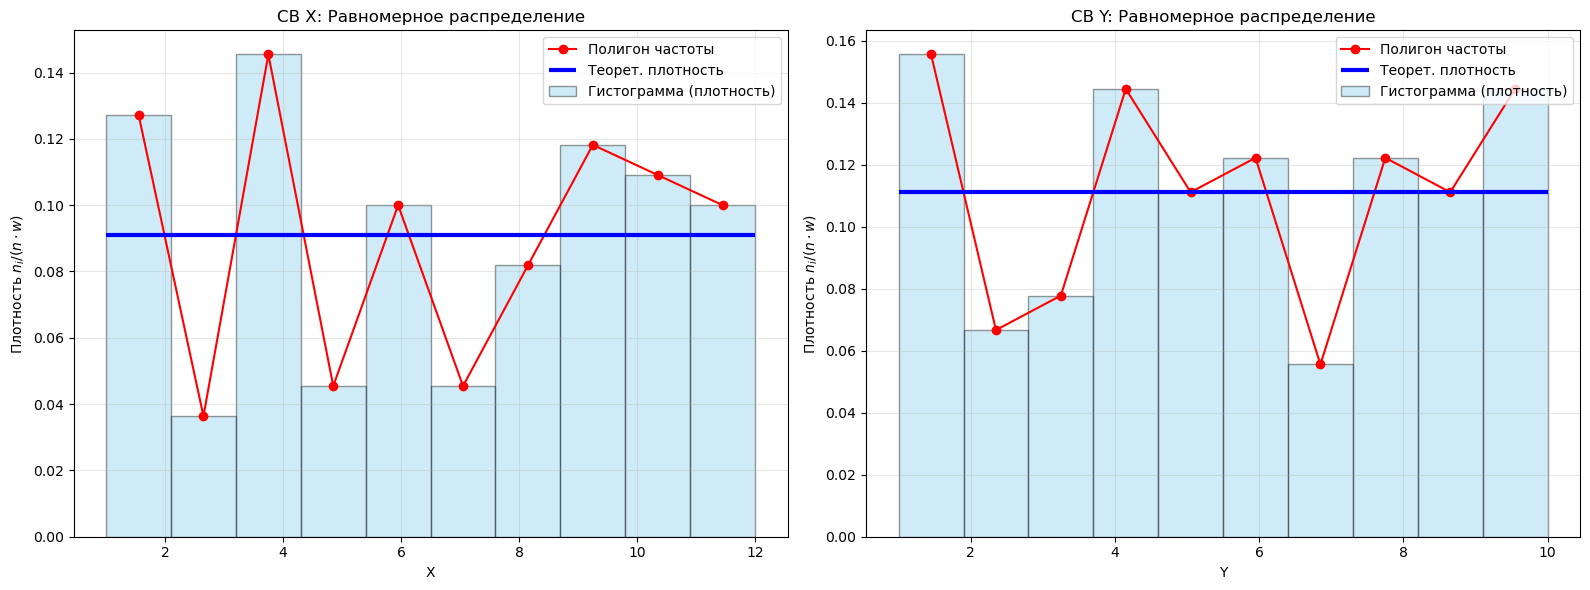

In [14]:
# 1. Параметры для СВ X
a_x, b_x = bins_x[0], bins_x[-1]
theory_x_val = 1 / (b_x - a_x)

# 2. Параметры для СВ Y
a_y, b_y = bins_y[0], bins_y[-1]
theory_y_val = 1 / (b_y - a_y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- ГРАФИК ДЛЯ СВ X ---
ax1.bar(bins_x[:-1], df_x['n_i/(n*w)'], width=w_x, color='skyblue', 
        edgecolor='black', alpha=0.4, align='edge', label='Гистограмма (плотность)')
ax1.plot(df_x['z_i'], df_x['n_i/(n*w)'], marker='o', color='red', label='Полигон частоты')

# Теоретическая плотность (равномерная)
ax1.hlines(y=theory_x_val, xmin=a_x, xmax=b_x, color='blue', lw=3, label='Теорет. плотность')

ax1.set_title('СВ X: Равномерное распределение')
ax1.set_xlabel('X')
ax1.set_ylabel('Плотность $n_i / (n \cdot w)$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- ГРАФИК ДЛЯ СВ Y ---
ax2.bar(bins_y[:-1], df_y['n_i']/(100*w_y), width=w_y, color='skyblue', 
        edgecolor='black', alpha=0.4, align='edge', label='Гистограмма (плотность)')
ax2.plot(df_y['z_i'], df_y['n_i']/(100*w_y), marker='o', color='red', label='Полигон частоты')

# Теоретическая плотность (равномерная)
ax2.hlines(y=theory_y_val, xmin=a_y, xmax=b_y, color='blue', lw=3, label='Теорет. плотность')

ax2.set_title('СВ Y: Равномерное распределение')
ax2.set_xlabel('Y')
ax2.set_ylabel('Плотность $n_i / (n \cdot w)$')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

11. Проверка гипотезы о выбранных распределениях используя критерий Хи-квадрат с уровнем значимости 0.05

In [17]:
from scipy.stats import chi2

alpha = 0.05

def check_uniform_hypothesis(df, n, label):
    # Количество интервалов
    k = len(df)
    # Теоретические частоты для равномерного распределения
    n_i_theory = n / k
    # Наблюдаемый хи квадрат
    chi_obs = ((df['n_i'] - n_i_theory)**2 / n_i_theory).sum()
    
    # Число степеней свободы
    # df = k - m - 1, где m - число оцененных параметров. 
    v = k - 2 - 1
    # Критическое значение
    chi_crit = chi2.ppf(1 - alpha, v)
    
    print(f"Проверка гипотезы для СВ {label}")
    print(f"Наблюдаемое значение Хи-квадрат: {chi_obs:.4f}")
    print(f"Критическое значение Хи-квадрат: {chi_crit:.4f}")
    print(f"Степеней свободы: {v}")
    
    if chi_obs < chi_crit:
        print(f"Результат: chi_obs < chi_crit. Гипотеза о равномерном распределении принимается (на уровне alpha={alpha})")
    else:
        print(f"Результат: chi_obs > chi_crit. Гипотеза о равномерном распределении отклоняется")
    print("\n")
check_uniform_hypothesis(df_x, 100, "X")
check_uniform_hypothesis(df_y, 100, "Y")

Проверка гипотезы для СВ X
Наблюдаемое значение Хи-квадрат: 15.4000
Критическое значение Хи-квадрат: 14.0671
Степеней свободы: 7
Результат: chi_obs > chi_crit. Гипотеза о равномерном распределении отклоняется


Проверка гипотезы для СВ Y
Наблюдаемое значение Хи-квадрат: 8.6000
Критическое значение Хи-квадрат: 14.0671
Степеней свободы: 7
Результат: chi_obs < chi_crit. Гипотеза о равномерном распределении принимается (на уровне alpha=0.05)




12. Поиск параметров уравнения линейной регрессии:

In [20]:
mean_x = sample_x.mean()
mean_y = sample_y.mean()
mean_xy = (sample_x * sample_y).mean()
mean_x_sq = (sample_x**2).mean()

# Знаменатель дисперсия X, числитель - ковариация
a_regr = (mean_xy - mean_x * mean_y) / (mean_x_sq - mean_x**2)
b_regr = mean_y - a_regr * mean_x

print(f"Параметры регрессии Y на X:")
print(f"a = {a_regr:.4f}")
print(f"b = {b_regr:.4f}")
print(f"Уравнение линейной регрессии: y = {a_regr:.4f}x + {b_regr:.4f}")

Параметры регрессии Y на X:
a = 0.0465
b = 5.2709
Уравнение линейной регрессии: y = 0.0465x + 5.2709


13. Вычисляем коэффициенты детерминации и корреляции:

In [22]:
# Коэффициент корреляции Пирсона
cov_xy = mean_xy - mean_x * mean_y
r_pearson = cov_xy / (std_sample_x * std_sample_y)

# Коэффициент детерминации
r_sq = r_pearson**2

print(f"Коэффициент корреляции Пирсона (r): {r_pearson:.4f}")
print(f"Коэффициент детерминации (R^2): {r_sq:.4f}")

Коэффициент корреляции Пирсона (r): 0.0527
Коэффициент детерминации (R^2): 0.0028


Линейная статистическая связь между переменными X и Y отсутствует.

14. Проверка значимости регрессии по критерию Фишера:

In [24]:
from scipy.stats import f
alpha = 0.05
# Число степеней свободы
df1 = 1           # для регрессии
df2 = n - 2       # для остатков

# Наблюдаемый F-критерий
f_obs = (r_sq / df1) / ((1 - r_sq) / df2)

# Критическое значение
f_crit = f.ppf(1 - alpha, df1, df2)

print(f"Наблюдаемое значение F-критерия: {f_obs:.4f}")
print(f"Критическое значение F-критерия (alpha={alpha}): {f_crit:.4f}")


Наблюдаемое значение F-критерия: 0.2728
Критическое значение F-критерия (alpha=0.05): 3.9381


Так как F наблюдаемое < F критического, уравнение регрессии статистически незначимое.

15. Диаграмма рассеяния и линия регрессии:

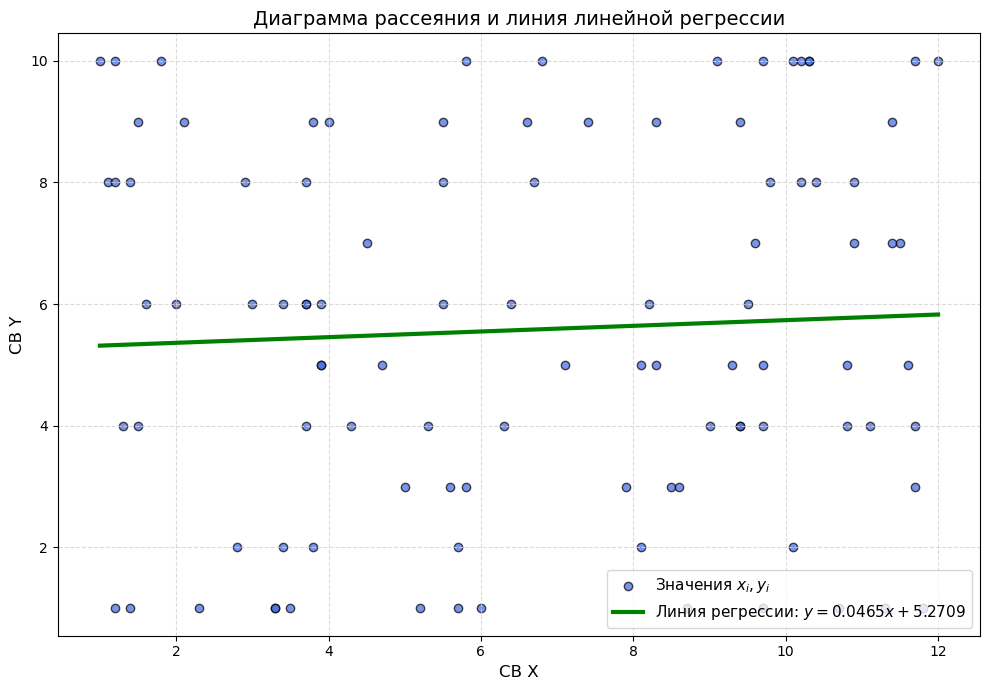

In [32]:
plt.figure(figsize=(10, 7))
plt.scatter(sample_x, sample_y, color='royalblue', edgecolor='black', alpha=0.7, label='Значения $x_i, y_i$')
x_range = np.linspace(min(sample_x), max(sample_x), 100)
y_regr = a_regr * x_range + b_regr
plt.plot(x_range, y_regr, color='green', lw=3, label=f'Линия регрессии: $y = {a_regr:.4f}x + {b_regr:.4f}$')

plt.title('Диаграмма рассеяния и линия линейной регрессии', fontsize=14)
plt.xlabel('СВ X', fontsize=12)
plt.ylabel('СВ Y', fontsize=12)
plt.grid(True, which='major', linestyle='--', color='lightgray', alpha=0.8)
plt.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()